In [3]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
from tqdm import tqdm
import matplotlib
import pickle as pi
from funcs_for_kappa import localgap_sys


import matplotlib.pyplot as plt
import cmasher as csh


matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [31]:
# model parameters
system_size = 10
A = 1.0
B = 1.0
onsite_disorder = 0
bond_power = 1.1
Delta = 2
# localizer parameters
E0 = 0.0
kappa = 1



# kappa vs E

In [ ]:
kappa_values = np.linspace(0, 25, 50)
E_values = np.linspace(-2.5, 2.5, 50)

localgap_grid = np.zeros((len(kappa_values), len(E_values)))

for i, kappa in tqdm(enumerate(kappa_values)):
    for j, E0 in enumerate(E_values):
        localgap_grid[i, j] = localgap_sys(
            system_size=system_size,
            Delta=Delta,
            A=A,
            B=B,
            bond_power=bond_power,
            onsite_disorder=onsite_disorder,
            E0=E0,
            kappa=kappa
        )
    
        
        

0it [00:00, ?it/s]

/opt/miniconda3/envs/peru_env/lib/python3.13/site-packages/scipy/sparse/linalg/_eigen/arpack/arpack.py:553: ComplexWarning: Casting complex values to real discards the imaginary part
  self.workd[yslice] = self.OP(self.workd[xslice])
/opt/miniconda3/envs/peru_env/lib/python3.13/site-packages/scipy/sparse/linalg/_eigen/arpack/arpack.py:568: ComplexWarning: Casting complex values to real discards the imaginary part
  self.workd[yslice] = self.OPa(self.workd[Bxslice])
50it [03:28,  4.18s/it]


In [106]:
pi.dump(localgap_grid, open("localgap_kappa_grid.pkl", "wb"))

Text(0, 0.5, '$E_0$')

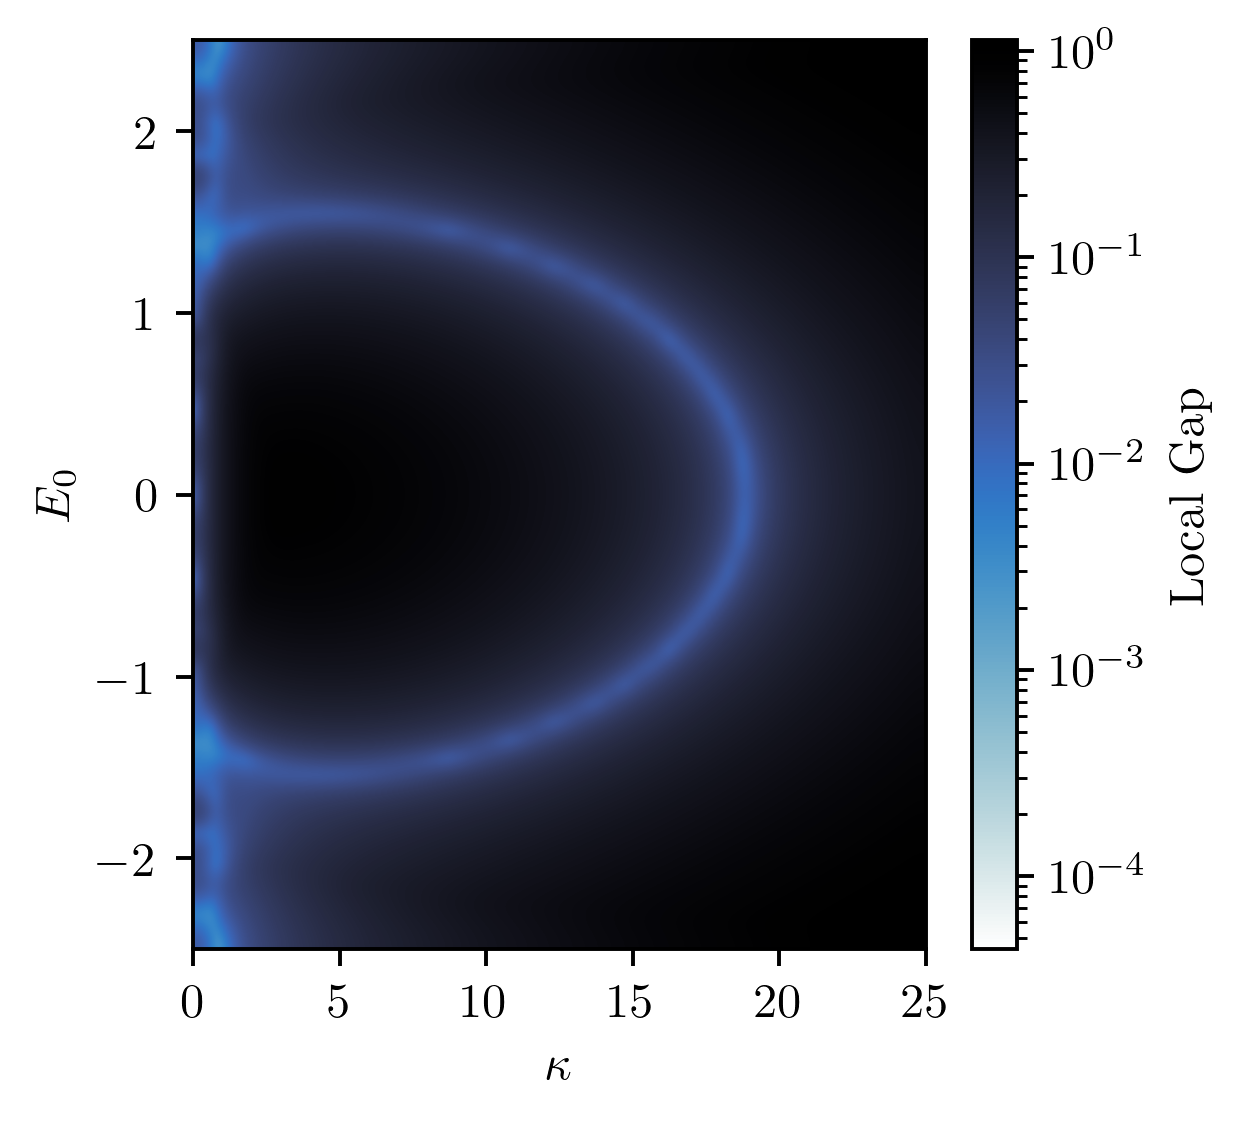

In [110]:

plt.figure(
    figsize=(aps_halfwidth, aps_halfwidth),
    dpi=350
)

im = plt.imshow(
    localgap_grid.T,
    extent=(kappa_values[0], kappa_values[-1], E_values[0], E_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log'
)
plt.colorbar(im, label='Local Gap')
plt.xlabel(r'$\kappa$')
plt.ylabel(r'$E_0$')
# plt.savefig("localgap_kappa_grid.png", bbox_inches='tight')

# Delta vs W

In [ ]:
from pathlib import Path
import re, os

folder =  Path.cwd() / "data"/"kappa-10"


g = []
def extract_E_value(filename):
    match = re.search(r'_seed_([-+]?[0-9]*\.?[0-9]+)', filename)
    if match:
        return float(match.group(1))
    return float('inf')  # Por si no encuentra el valor

print(sorted(os.listdir(folder), key=extract_E_value))

for file in sorted(os.listdir(folder), key=extract_E_value):
    g.append(pi.load(open(os.path.join(folder, file), 'rb')))

g = np.array(g)

['localgap_kappa_1_seed_0.0.pkl', 'localgap_kappa_1_seed_1.0.pkl', 'localgap_kappa_1_seed_2.0.pkl', 'localgap_kappa_1_seed_3.0.pkl', 'localgap_kappa_1_seed_4.0.pkl', 'localgap_kappa_1_seed_5.0.pkl', 'localgap_kappa_1_seed_6.0.pkl', 'localgap_kappa_1_seed_7.0.pkl', 'localgap_kappa_1_seed_8.0.pkl', 'localgap_kappa_1_seed_9.0.pkl', 'localgap_kappa_1_seed_10.0.pkl', 'localgap_kappa_1_seed_11.0.pkl', 'localgap_kappa_1_seed_12.0.pkl', 'localgap_kappa_1_seed_13.0.pkl', 'localgap_kappa_1_seed_14.0.pkl', 'localgap_kappa_1_seed_15.0.pkl', 'localgap_kappa_1_seed_16.0.pkl', 'localgap_kappa_1_seed_17.0.pkl', 'localgap_kappa_1_seed_18.0.pkl', 'localgap_kappa_1_seed_19.0.pkl', 'localgap_kappa_1_seed_20.0.pkl', 'localgap_kappa_1_seed_21.0.pkl', 'localgap_kappa_1_seed_22.0.pkl', 'localgap_kappa_1_seed_23.0.pkl', 'localgap_kappa_1_seed_24.0.pkl', 'localgap_kappa_1_seed_25.0.pkl', 'localgap_kappa_1_seed_26.0.pkl', 'localgap_kappa_1_seed_27.0.pkl', 'localgap_kappa_1_seed_28.0.pkl', 'localgap_kappa_1_seed_

In [ ]:
avg_locgap = np.mean(g, axis=0)

Text(0, 0.5, '$W$')

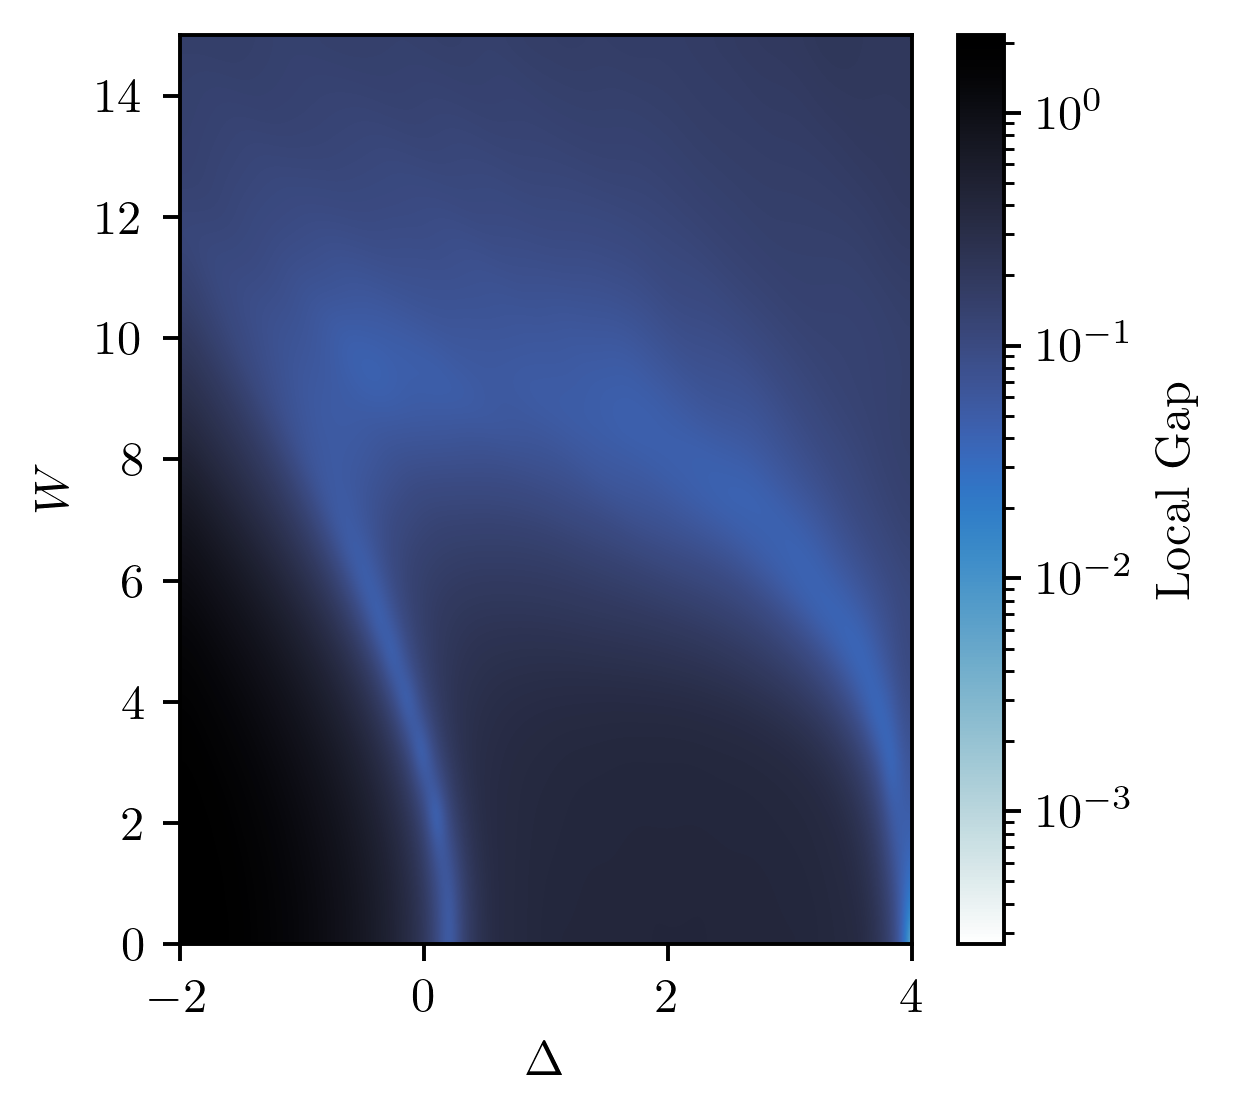

In [ ]:
Delta_values = np.linspace(-2, 4, 50)
W_values = np.linspace(0, 15, 50)

plt.figure(
    figsize=(aps_halfwidth, aps_halfwidth),
    dpi=350
)

im = plt.imshow(
    avg_locgap.T,
    extent=(Delta_values[0], Delta_values[-1], W_values[0], W_values[-1]),
    origin="lower",
    aspect="auto",
    cmap=csh.arctic_r,
    interpolation='bicubic',
    norm='log'
)
plt.colorbar(im, label='Local Gap')
plt.xlabel(r'$\Delta$')
plt.ylabel(r'$W$')
# plt.savefig("localgap_kappa_grid.png", bbox_inches='tight')

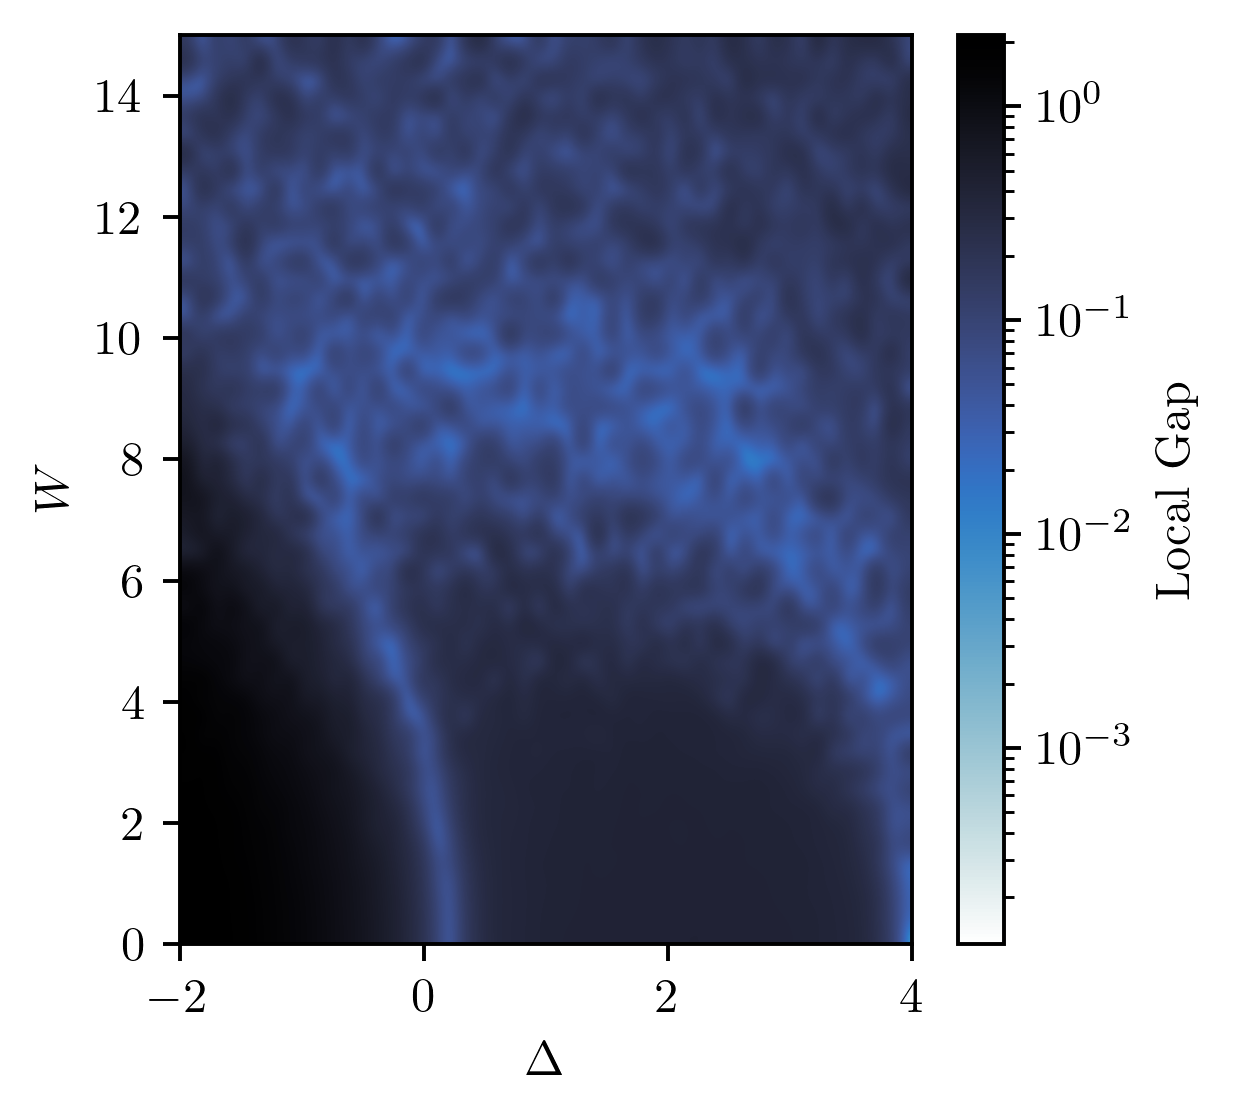